This code allows for the following: 

Imports: 
.txt files with distributions of a full contact potential difference image. 

Functions:
- Fitting individual gaussians with fit centre marked and FWHM shaded. 
- Plots raw data and fitted distributions on same plot for comparison. 


Use for: 
- Comparing CPD distributions of different images. 
- Comparing spread


In [1]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [2]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
file_path_unpassivated = filedialog.askopenfilename(title='Select unpassivated .txt file')
file_path_passivated = filedialog.askopenfilename(title='Select passivated .txt file')
save_path = filedialog.askdirectory(title='Select Folder to Save Plot')

    
def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=600, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")

If pop up box not seen minimise spyder and select folder wanted for analysis


In [3]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink


GB_U_color = "#5CBBFF"
GI_U_color = "#003357"
GB_P_color = "#D69AAB"
GI_P_color = "#8D1730"

In [4]:
#Fitting for multi-gaussian
#Adjust peak width tolerance accordingly

# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y

In [5]:
# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


In [20]:
#Multi-gaussian fitting for all files within file directory
def multi_gaussian_folder(file_path, rows, linecolour, name):

    #Plotting parameters
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 12
    scatter_size = 6
    line_width = 1.5
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both')
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)")
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)")
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    results = []
    #print(f"\nProcessing file: {filename}") #Use if you want each individual file processed

    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        data = np.loadtxt(f, skiprows=rows)

    x_data = data[:, 0]
    y_data = data[:, 1]
            
    # Estimate initial guess and peak count
    initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
    min_raw=np.min(x_data)
    max_raw=np.max(x_data)
    mean_raw=np.mean(x_data)
    #x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    popt, pcov = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
    y_fit=multi_gaussian(x_data,*popt)
    peak_index_max=np.argmax(y_fit)
    x_peak_centre=x_data[peak_index_max]
    perr=np.sqrt(np.diag(pcov))
    #For finding min and max *i.e. either side of the peaks. 
    # Extract Gaussian parameters
    gaussians = []
    for i in range(len(popt) // 3):
        amp = popt[i*3]
        cen = popt[i*3+1]
        wid = abs(popt[i*3+2])
        gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

    # Identify the highest peak
    #highest = max(gaussians, key=lambda g: g['amp'])
    highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
# FWHM = 2.355 * sigma
    sigma=highest['wid']
    fwhm = 2.355 *sigma
    x_left = highest['cen'] - fwhm / 2
    x_right = highest['cen'] + fwhm / 2
    
    # Store in lists for output

    # Optional: print for debugging
    # 3. Create the summary text for the plot
    statistics=(f"Peak: {highest['cen']*1000:.3f} mV\n"
              f"FWHM: {fwhm*1000:.2f} mV\n"
              f"Sigma: {sigma*1000:.3f} mV"
              f"Bounds: [{x_left*1000:.2f}, {x_right*1000:.2f}]mV")
    print(statistics) 
    if n_peaks is not None:
   
        # Shading spread and peak centre
        ax.axvspan(x_left, x_right, color='gray', alpha=0.2, label='FWHM Region', zorder=0)
        ax.axvline(x=highest['cen'], color='black', linestyle='--', linewidth=line_width, label='Peak Center', zorder=4)
        #Raw data and fitted gaussian: 
        ax.scatter(x_data, y_data, label=f"name",color=linecolour, s=scatter_size, zorder=2)
        ax.plot(x_data, multi_gaussian(x_data, *popt), label=f"_nolegend_", color=linecolour,linewidth=line_width, zorder=3)
        #Labelling and layout adjustment
        '''ax.text(0.95,0.95,statistics, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='right', 
                facecolor='white', alpha=0.8, edgecolour=None,
                fontweight='bold', fontsize=10)'''
        ax.set_xlabel("CPD(V)")
        ax.set_ylabel("Distribution $V^{-1}$")
        ax.autoscale()
        #plt.legend()
        plt.tight_layout()
        #plt.show()
    y_fit = multi_gaussian(x_data, *popt)
    #plt.autoscale(enable=True, axis='y', tight=False)
    #Uncomment for file saving
    fig=plt.gcf()
    save_plot_to_folder(fig,save_path,filename=f'FittingAnnotation_{name}.jpeg')
    return x_data, y_data, y_fit, statistics, perr
    plt.show()    

Peak: -997.002 mV
FWHM: 45.74 mV
Sigma: 19.421 mVBounds: [-1019.87, -974.13]mV
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/CPDHistogramsForAnnotation\FittingAnnotation_Unpassivated.jpeg
Peak: -567.073 mV
FWHM: 14.64 mV
Sigma: 6.216 mVBounds: [-574.39, -559.75]mV
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/CPDHistogramsForAnnotation\FittingAnnotation_Passivated.jpeg


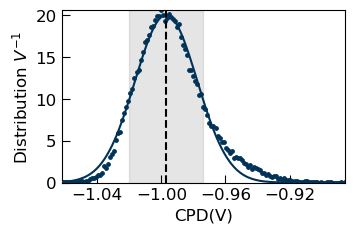

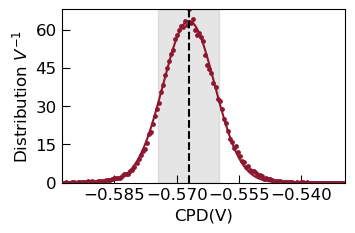

In [21]:
#Running all plots: 

unpass_x, unpass_y, unpass_fit,unpass_stats, perr_unpass = multi_gaussian_folder(file_path_unpassivated, rows=3, linecolour=GI_U_color, name="Unpassivated")
pass_x, pass_y, pass_fit,pass_stats, perr_pass = multi_gaussian_folder(file_path_passivated, rows=3, linecolour=GI_P_color, name="Passivated")

In [15]:
print(perr_unpass[2]*1000)
print(perr_pass[2]*1000)

0.1947304271258571
0.02628757507359411


In [8]:
unpass_x_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in unpass_x]
pass_x_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in pass_x]

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/1 - KPFM/Grain Analysis/CPDHistogramsForAnnotation\Fitting_scatter_both.jpeg


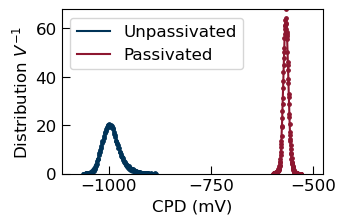

In [9]:
#Plotting both together
dpi_setting = 600
figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
tick_length = 6
legend_font = 12
base_font_size = 15
scatter_size = 6
line_width = 1.5


fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
plt.rcParams.update({'font.size': base_font_size})
ax = plt.gca()
ax.tick_params(direction='in', length=tick_length)
ax.tick_params(axis='both')
ax.margins (0.5,0.5)
plt.xlabel("SPV (V)")
ax.autoscale(enable=None, axis="x", tight=True)
plt.ylabel("Distribution (V$^{-1}$)")
# Limit number of ticks
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))  # Max 5 ticks on x-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Max 5 ticks on y-axis    
ax.scatter(unpass_x_mV, unpass_y, label=f"_nolegend_",color=GI_U_color, s=scatter_size, zorder=2)
ax.plot(unpass_x_mV, unpass_fit, label=f"Unpassivated", color=GI_U_color,linewidth=line_width, zorder=3)
ax.scatter(pass_x_mV, pass_y, label=f"_nolegend_",color=GI_P_color, s=scatter_size, zorder=2)
ax.plot(pass_x_mV, pass_fit, label=f"Passivated", color=GI_P_color,linewidth=line_width, zorder=3)
ax.set_xlabel("CPD (mV)")
ax.set_ylabel("Distribution $V^{-1}$")
ax.autoscale()
plt.margins(0.1,0)
plt.legend(loc='best', fontsize=legend_font)
plt.tight_layout()

fig=plt.gcf()
save_plot_to_folder(fig,save_path,filename=f'Fitting_scatter_both.jpeg')
plt.show()
